# twowaypanel — Examples Gallery (Notebook)

This notebook contains the executable code for the `twowaypanel` **Examples Gallery** in the online documentation:

- https://twowaypanel.readthedocs.io/en/latest/examples/examples.html

For tutorials and the full API reference, see the documentation homepage:

- https://twowaypanel.readthedocs.io/


# Import and setup

In [1]:
import numpy as np
import twowaypanel

# Example 1: Binary logit with strictly exogenous regressors (Angrist and Evans 1998)

In [2]:
data = twowaypanel.database.angristevans98()

# Typical workflow (exact variable names depend on the shipped dataset):
data = data.sort_values(["id", "year"])
N = data["id"].nunique()
T = data["year"].nunique()

# Y: LFP (N x T)
lfp = data["lfp"].to_numpy().reshape(N, T)

# X: covariates (N x T x K)
X_static  = data.loc[:,['kids0_2','kids3_5','kids6_17','ln_husincome']].to_numpy().reshape(N,T,4)
X_dynamic  = data.loc[:,['lag_lfp','kids0_2','kids3_5','kids6_17','ln_husincome']].to_numpy().reshape(N,T,5)
X_static_names = ["Kids 0–2", "Kids 3–5", "Kids 6–17", "ln(hus inc)"]
X_dynamic_names = ["LFP_t-1", "Kids 0–2", "Kids 3–5", "Kids 6–17", "ln(hus inc)"]

Joint MLE (no bias correction)

In [3]:
res_mle = twowaypanel.fit(
    lfp, X_static,
    model="logit", prior=None,
    algorithm="JML",
    X_names=X_static_names
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
                 LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                           WITHOUT BIAS CORRECTION
--------------------------------------------------------------------------------
Number of Individuals:   664                              Observations:     5976
Number of Time Periods:    9                            Log-likelihood: -3033.74
Algorithm: Joint MLE                              Time spent (seconds):    1.098
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
            Kids 0–2    -1.17434565    0.09836036   0.000    -1.36712   -0.98156
            Kids 3–5    -0.59134501    0.08622960   0.000    -0.76034   -0.4

# Example 2: Binary logit with strictly exogenous regressors + model-specific prior (MCMC) + convergence diagnostics

100%|███████████████████████████████████████████████████████████████████████| 150000/150000 [59:00:49<00:00,  1.42s/it]



--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
                 LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
             USING BIAS-REDUCING PRIOR FOR EXPONENTIAL FAMILY MODELS
                      WITH STRICTLY EXOGENOUS REGRESSORS
--------------------------------------------------------------------------------
Number of Individuals:   664                              Observations:     5976
Number of Time Periods:    9   
Algorithm: Markov Chain Monte Carlo               Time spent (minutes): 3540.872
           150000 reptitions
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
            Kids 0–2    -0.96974154    0.09139083   0.000    -1.14885   -0.79062
            Kids 3–5 

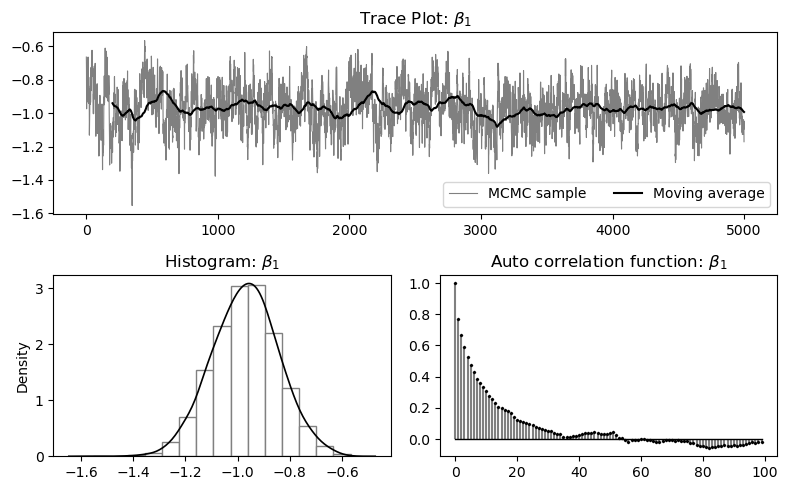

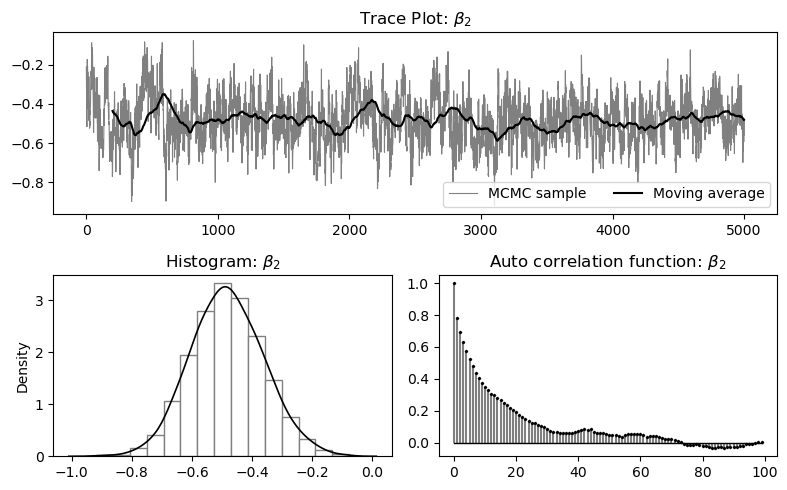

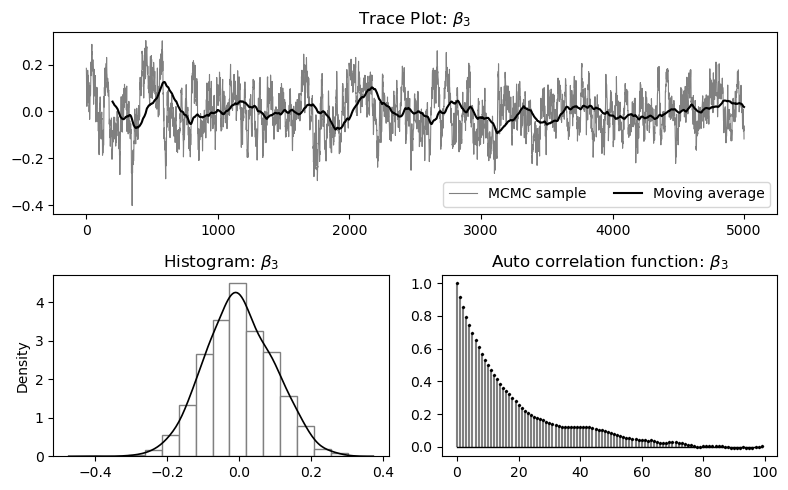

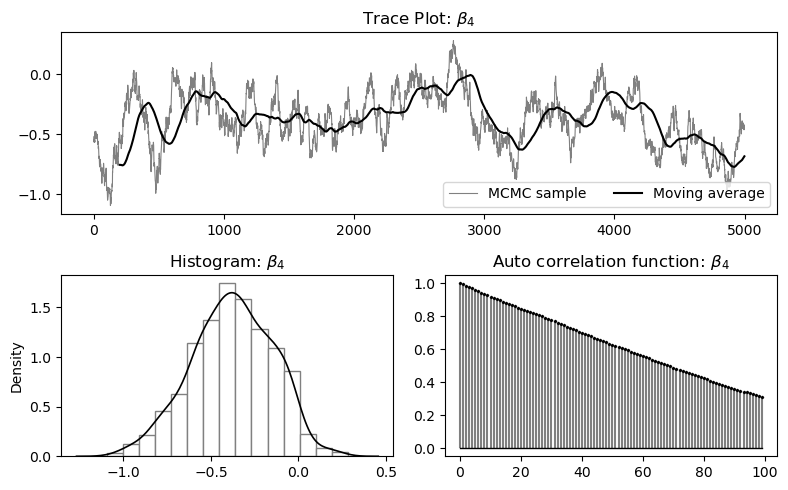

In [4]:
beta_variance = np.array([np.sqrt(1e-1),np.sqrt(1e-2),np.sqrt(1e-2),np.sqrt(5e-5),np.sqrt(5e-7)])

res_mcmc = twowaypanel.fit(
    lfp, X_static,
    model="logit", prior="SE", algorithm="MCMC",
    X_names=X_static_names,
    beta_variance=beta_variance,fe_variance=0.1,
    mcmc_iters=150000, mcmc_burnin=50000, mcmc_skipsize=20,
    mcmc_timer=1, mcmc_sv_mle=True, mcmc_diagnosis=True
)

# Example 3: Analytical bias correction (Fernández-Val and Weidner, 2016)

In [5]:
res_fw16 = twowaypanel.fit(
    lfp, X_static,
    model="logit", prior=None, ac=True,
    algorithm="JML",
    X_names=X_static_names
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
                 LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                ANALYTICAL BIAS CORRECTION ON ESTIMATOR (FW16)
--------------------------------------------------------------------------------
Number of Individuals:   664                              Observations:     5976
Number of Time Periods:    9                            Log-likelihood: -3033.74
Algorithm: Joint MLE                              Time spent (seconds):    2.425
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
            Kids 0–2    -1.02689349    0.09836036   0.000    -1.21966   -0.83411
            Kids 3–5    -0.51776197    0.08622960   0.000    -0.

# Example 4: Dynamic probit with generic prior

In [6]:
res_dyn = twowaypanel.fit(
    lfp, X_dynamic,
    model="probit", prior="Generic", lag=1,
    algorithm="JML",
    X_names=X_dynamic_names
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
                 PROBIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                  USING BIAS-REDUCING PRIOR (GENERIC VERSION)
--------------------------------------------------------------------------------
Number of Individuals:   664                              Observations:     5976
Number of Time Periods:    9                            Log-likelihood: -3148.29
Algorithm: Joint MLE                              Time spent (seconds):    1.800
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
             LFP_t-1    0.970193330    0.04268741   0.000    0.886530   1.053856
            Kids 0–2    -0.46261536    0.05690305   0.000    -0.

# Example 5: Ordered logit (simulated data)

In [7]:
# Generate a dynamic ordered-logit panel (returns long-form arrays by default)
FEi, FEt, FE, index_i, index_t, Y, X, Ystar, alphas0, gammas0 = twowaypanel.demo.PanelGenData(
    N=45, T=15, seed=10, model="ologit", dynamic=1
)

# Reshape into N x T and N x T x K
Y = Y.reshape(45, 15)
X = X.reshape(45, 15, 2)

In [8]:
res_ologit_mle = twowaypanel.fit(
    Y, X, model="ologit",
    prior=None, algorithm="JML", 
    cutoff0=-2.5,      # identification normalization
)



--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
               ORDERED LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                           WITHOUT BIAS CORRECTION
--------------------------------------------------------------------------------
Number of Individuals:    45                              Observations:      675
Number of Time Periods:   15                            Log-likelihood:  -685.19
Algorithm: Joint MLE                              Time spent (seconds):    0.096
--------------------------------------------------------------------------------
                        Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
                  X1    0.441343774    0.18110680   0.015    0.086392   0.796295
                  X2    1.241542606    0.11763947   0.000    1.010980 

In [9]:
res_ologit_generic = twowaypanel.fit(
    Y, X, model="ologit",
    prior="Generic", algorithm="JML", lag=1,
    cutoff0=-2.5,
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
               ORDERED LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                  USING BIAS-REDUCING PRIOR (GENERIC VERSION)
--------------------------------------------------------------------------------
Number of Individuals:    45                              Observations:      675
Number of Time Periods:   15                            Log-likelihood:  -711.48
Algorithm: Joint MLE                              Time spent (seconds):    0.116
--------------------------------------------------------------------------------
                        Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
                  X1    0.571509060    0.17854978   0.001    0.221569   0.921448
                  X2    1.169471961    0.11501164   0.000  

100%|████████████████████████████████████████████████████████████████████████| 120000/120000 [2:57:41<00:00, 11.26it/s]



--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
               ORDERED LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                  USING BIAS-REDUCING PRIOR (GENERIC VERSION)
--------------------------------------------------------------------------------
Number of Individuals:    45                              Observations:      225
Number of Time Periods:   15   
Algorithm: Markov Chain Monte Carlo               Time spent (minutes):  177.691
           120000 reptitions
--------------------------------------------------------------------------------
                        Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
                  X1    0.568049498    0.17823331   0.001    0.218730   0.917368
                  X2    1.167454158    0.11479293   0.000    0.942471   1.39243

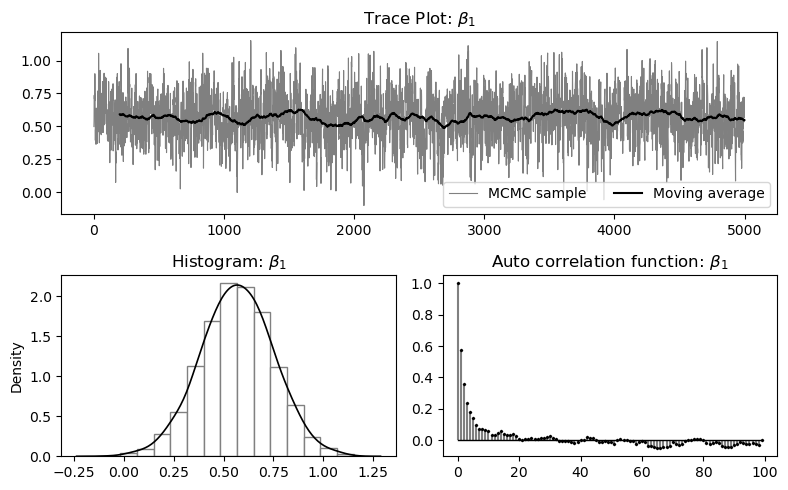

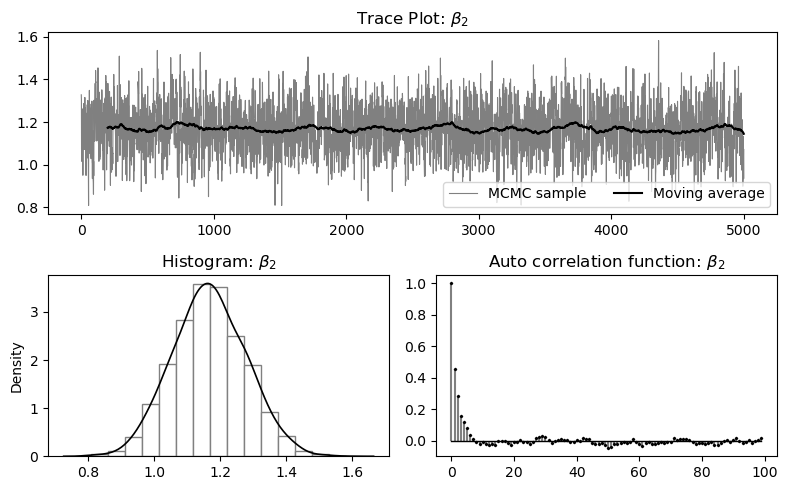

In [10]:
res_ologit_mcmc = twowaypanel.fit(
    Y, X, model="ologit",
    prior="Generic", algorithm="MCMC", lag=1,
    cutoff0=-2.5,
    mcmc_iters=120000, mcmc_burnin=20000, mcmc_skipsize=20, mcmc_diagnosis=True
)

# Example 6: Multinomial logit (simulated data)

In [11]:
_, _, _, _, _, Y, X, _, _, _ = twowaypanel.demo.PanelGenData(
    N=45, T=15, seed=10, model="mlogit", dynamic=1
)
Y = Y.reshape(45, 15)
X = X.reshape(45, 15, 2)

# Uncorrected JML
res_mlogit_mle = twowaypanel.fit(
    Y, X, model="mlogit",
    prior=None, algorithm="JML"
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
             MULTINOMIAL LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
                           WITHOUT BIAS CORRECTION
--------------------------------------------------------------------------------
Number of Individuals:    44                              Observations:      660
Number of Time Periods:   15                            Log-likelihood:  -590.37
Algorithm: Joint MLE                              Time spent (seconds):    0.810
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
  Y = 2
                  X1    -0.02201089    0.25903835   0.932    -0.52970   0.485678
                  X2    1.006845054    0.17222417   0.000   

In [12]:
res_mlogit_dml = twowaypanel.fit(
    Y, X,
    model="mlogit", prior="PML", lag=1,
    algorithm="JML"
)


--------------------------------------------------------------------------------
---- ESTIMATION RESULTS --------------------------------------------------------
             MULTINOMIAL LOGIT PANEL MODEL WITH TWO-WAY FIXED EFFECTS
             USING BIAS-REDUCING PRIOR FOR EXPONENTIAL FAMILY MODELS
                         WITH PREDETERMINED REGRESSORS
--------------------------------------------------------------------------------
Number of Individuals:    44                              Observations:      660
Number of Time Periods:   15                            Log-likelihood:  -520.18
Algorithm: Joint MLE                              Time spent (seconds):    4.762
--------------------------------------------------------------------------------
Independent variable    Coefficient     Std. Err.   P>|z|   [95% conf. interval]
--------------------------------------------------------------------------------
  Y = 2
                  X1    0.284336843    0.25121981   0.258    -0.2080